# Model Construction

In [19]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [4]:
train_data_df = pd.read_csv("../data/train/train.csv")
test_data_df = pd.read_csv("../data/test/test.csv")
val_data_df = pd.read_csv("../data/val/val.csv")

X_train_data = train_data_df.drop(columns=["Diagnosis"]).to_numpy()
y_train_data = train_data_df["Diagnosis"].to_numpy()

X_test_data = test_data_df.drop(columns=["Diagnosis"]).to_numpy()
y_test_data = test_data_df["Diagnosis"].to_numpy()

X_val_data = val_data_df.drop(columns=["Diagnosis"]).to_numpy()
y_val_data = val_data_df["Diagnosis"].to_numpy()

In [6]:
X_train_data.shape, X_val_data.shape, X_test_data.shape

((398, 30), (85, 30), (86, 30))

In [13]:
Lg = LogisticRegression(
    solver="liblinear",
    max_iter=5000,
    random_state=42
)
Lg.fit(X_train_data, y_train_data)

y_test_prediction=Lg.predict(X_test_data)
y_val_prediction= Lg.predict(X_val_data)

In [14]:
print("Validation Accuracy:", accuracy_score(y_val_data, y_val_prediction))
print("Validation Recall:", recall_score(y_val_data, y_val_prediction))
print("Validation Precision:", precision_score(y_val_data, y_val_prediction))
print("Validation F1:", f1_score(y_val_data, y_val_prediction))

print("\nTest Accuracy:", accuracy_score(y_test_data, y_test_prediction))
print("Test Recall:", recall_score(y_test_data, y_test_prediction))
print("Test Precision:", precision_score(y_test_data, y_test_prediction))
print("Test F1:", f1_score(y_test_data, y_test_prediction))

Validation Accuracy: 0.9647058823529412
Validation Recall: 0.90625
Validation Precision: 1.0
Validation F1: 0.9508196721311475

Test Accuracy: 0.9767441860465116
Test Recall: 0.96875
Test Precision: 0.96875
Test F1: 0.96875


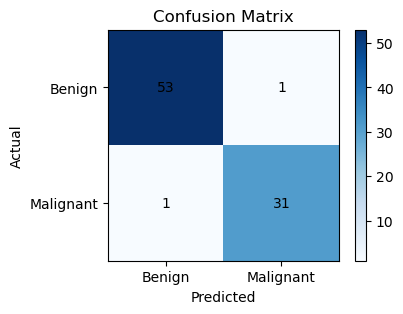

In [20]:
#confusion matrix
cm = confusion_matrix(y_test_data, y_test_prediction)
plt.figure(figsize=(4,3))
plt.imshow(cm, cmap='Blues')  
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(np.arange(2), ["Benign", "Malignant"])
plt.yticks(np.arange(2), ["Benign", "Malignant"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

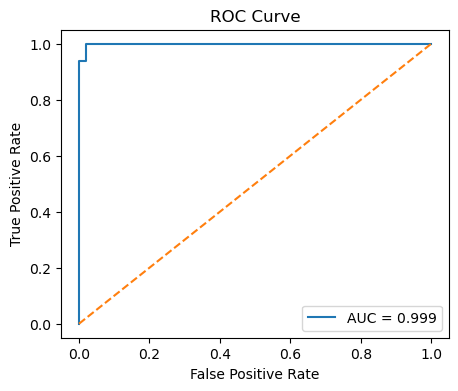

In [23]:
y_test_prob = Lg.predict_proba(X_test_data)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test_data, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label="AUC = {:.3f}".format(roc_auc))
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [31]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# ----- device -----
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

# ----- convert numpy → tensors -----
X_train_t = torch.tensor(X_train_data, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_data, dtype=torch.float32).unsqueeze(1).to(device)

X_val_t = torch.tensor(X_val_data, dtype=torch.float32).to(device)
y_val_t = torch.tensor(y_val_data, dtype=torch.float32).unsqueeze(1).to(device)

X_test_t = torch.tensor(X_test_data, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test_data, dtype=torch.float32).unsqueeze(1).to(device)

# DataLoader for mini-batches
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)


Using device: mps


In [32]:
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)   # output = 1 logit
        )
    def forward(self, x):
        return self.net(x)  # raw logits

input_dim = X_train_data.shape[1]  # 30 features
model = SimpleNN(input_dim).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [33]:
num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(1, num_epochs + 1):
    # ----- train -----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * xb.size(0)
        
        # accuracy on this batch
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        correct += (preds == yb).sum().item()
        total += xb.size(0)

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    #test
    model.eval()
    with torch.no_grad():

        logits_test = model(X_test_t)
        test_loss = criterion(logits_test, y_test_t).item()

        probs_test = torch.sigmoid(logits_test)
        preds_test = (probs_test >= 0.5).float()
        correct_test = (preds_test == y_test_t).sum().item()
        total_test = y_test_t.size(0)
        test_acc = correct_test / total_test

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    
    # ----- validation -----
    model.eval()
    with torch.no_grad():
        logits_val = model(X_val_t)
        val_loss = criterion(logits_val, y_val_t).item()
        
        probs_val = torch.sigmoid(logits_val)
        preds_val = (probs_val >= 0.5).float()
        correct_val = (preds_val == y_val_t).sum().item()
        total_val = y_val_t.size(0)
        val_acc = correct_val / total_val
    
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    # print progress
    print(f"Epoch {epoch:02d}: "
          f"Train Loss={epoch_train_loss:.4f}, Test Loss={test_loss:.4f}, "
          f"Train Acc={epoch_train_acc:.3f}, Test Acc={test_acc:.3f}")


Epoch 01: Train Loss=0.4788, Test Loss=0.1883, Train Acc=0.814, Test Acc=0.965
Epoch 02: Train Loss=0.1526, Test Loss=0.0698, Train Acc=0.957, Test Acc=0.977
Epoch 03: Train Loss=0.0900, Test Loss=0.0464, Train Acc=0.980, Test Acc=0.988
Epoch 04: Train Loss=0.0746, Test Loss=0.0394, Train Acc=0.982, Test Acc=0.988
Epoch 05: Train Loss=0.0673, Test Loss=0.0396, Train Acc=0.980, Test Acc=0.988
Epoch 06: Train Loss=0.0601, Test Loss=0.0400, Train Acc=0.980, Test Acc=0.988
Epoch 07: Train Loss=0.0550, Test Loss=0.0358, Train Acc=0.985, Test Acc=0.988
Epoch 08: Train Loss=0.0516, Test Loss=0.0388, Train Acc=0.990, Test Acc=0.988
Epoch 09: Train Loss=0.0499, Test Loss=0.0379, Train Acc=0.990, Test Acc=0.988
Epoch 10: Train Loss=0.0469, Test Loss=0.0349, Train Acc=0.992, Test Acc=0.977
Epoch 11: Train Loss=0.0423, Test Loss=0.0411, Train Acc=0.992, Test Acc=0.977
Epoch 12: Train Loss=0.0360, Test Loss=0.0358, Train Acc=0.992, Test Acc=0.977
Epoch 13: Train Loss=0.0345, Test Loss=0.0469, Train

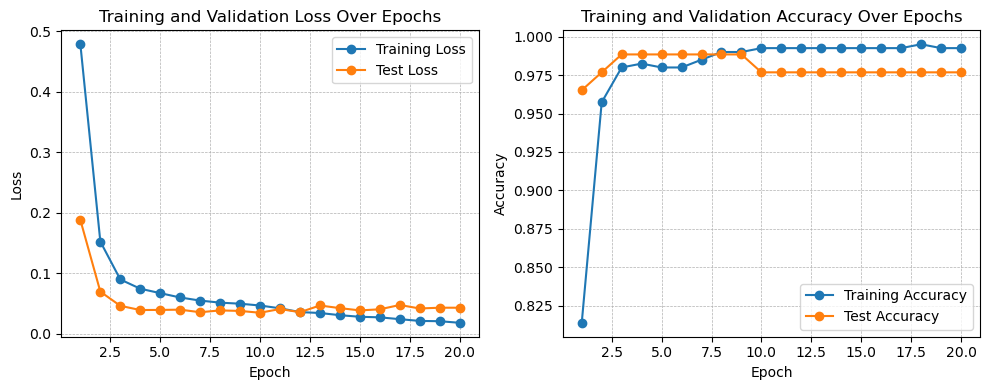

In [34]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(10,4))

# ----- Loss -----
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, marker='o', label='Training Loss')
plt.plot(epochs, test_losses,   marker='o', label='Test Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.grid(linestyle='--', linewidth=0.5)


plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(epochs, test_accuracies,   marker='o', label='Test Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy Over Epochs")
plt.legend()
plt.grid(linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()
